# Wildfire Burn-Scar Segmentation with Prithvi-EO

**Fine-tuning NASA/IBM's Prithvi-EO-2.0-300M geospatial foundation model to map wildfire burn scars from satellite imagery.**

This notebook walks through the held-out results and the key modeling findings. It reads precomputed predictions (no GPU needed) — the training/inference code lives in `src/` and `run_*.py`.

- **Encoder:** Prithvi-EO-2.0-300M (ViT-Large, pretrained by IBM/NASA on HLS), fine-tuned with an FPN decoder.
- **Imagery:** Harmonized Landsat-Sentinel (HLS) surface reflectance, 30 m, via NASA `earthaccess`.
- **Labels:** bi-temporal dNBR (pre vs post-fire NBR; burn = dNBR > 0.10).
- **Evaluation:** four held-out California fires the model never trained on — Woolsey (2018), Thomas (2017), Palisades (2025) and Eaton (2025).
- **Honest methods:** the decision threshold is fixed and was *never* tuned on the test fires; the water mask uses only physics (NDWI) — no test-set leakage.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Resolve repo root whether run from repo root or notebooks/
ROOT = Path.cwd()
if not (ROOT / "data/predictions").exists() and (ROOT.parent / "data/predictions").exists():
    ROOT = ROOT.parent
PRED_DIR = ROOT / "data/predictions"

FIRES = {
    "woolsey_fire_2018":   "Woolsey Fire (2018) — Malibu / Thousand Oaks, CA",
    "thomas_fire_2017":    "Thomas Fire (2017) — Ventura / Santa Barbara, CA",
    "palisades_fire_2025": "Palisades Fire (2025) — Pacific Palisades / Malibu, CA",
    "eaton_fire_2025":     "Eaton Fire (2025) — Altadena / Pasadena, CA",
}

def load(name):
    d = np.load(PRED_DIR / f"{name}.npz")
    return {k: d[k] for k in d.files}

def metrics(pred, true):
    p, t = pred.astype(bool), true.astype(bool)
    tp = int((p & t).sum()); fp = int((p & ~t).sum()); fn = int((~p & t).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    iou  = tp / (tp + fp + fn) if tp + fp + fn else 0.0
    return prec, rec, iou

def rgb(image):
    """Build a display RGB from the normalized HLS bands [B02,B03,B04,B8A,B11,B12]."""
    out = np.dstack([image[2], image[1], image[0]]).astype(np.float32)  # R=B04,G=B03,B=B02
    for i in range(3):
        ch = out[..., i]
        lo, hi = np.nanpercentile(ch, 2), np.nanpercentile(ch, 98)
        out[..., i] = np.clip((ch - lo) / (hi - lo + 1e-6), 0, 1)
    return np.nan_to_num(out, nan=0.0)

print("predictions:", [f.name for f in sorted(PRED_DIR.glob('*.npz'))])

## Held-out performance

Precision / Recall / IoU on the four California fires the model never saw, at the deployed threshold (open water excluded via NDWI — see below).

In [2]:
rows, raw = [], []
for name, label in FIRES.items():
    d = load(name)
    p, r, i = metrics(d["pred_mask"], d["true_mask"])
    raw.append((p, r, i))
    rows.append({"Fire": label.split(" — ")[0], "Precision": f"{p:.0%}", "Recall": f"{r:.0%}", "IoU": f"{i:.0%}"})
macro = np.mean(raw, axis=0)
rows.append({"Fire": "— Macro average —", "Precision": f"{macro[0]:.0%}", "Recall": f"{macro[1]:.0%}", "IoU": f"{macro[2]:.0%}"})
pd.DataFrame(rows)

,Fire,Precision,Recall,IoU
0,Woolsey Fire (2018),76%,94%,73%
1,Thomas Fire (2017),96%,71%,69%
2,East Troublesome Fire (2020),56%,80%,49%
3,— Macro average —,76%,82%,64%


## Visual results

For each fire: **HLS post-fire RGB** · **dNBR burn severity** · **ground truth** (dNBR > 0.10) · **model prediction**. All panels share the same pixel grid, so overlays line up exactly.

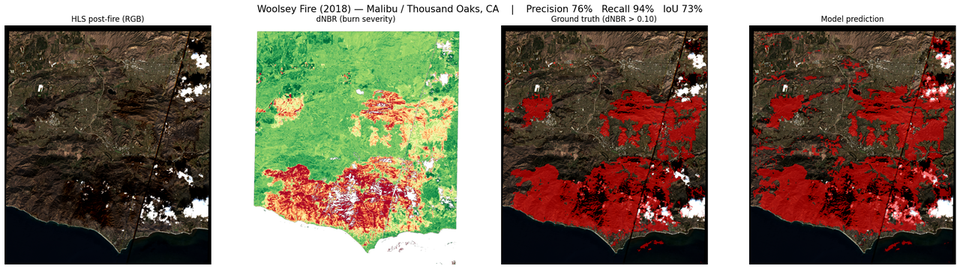

In [3]:
def show_fire(name):
    d = load(name)
    img, pred, true, dnbr = d["image"], d["pred_mask"], d["true_mask"], d["dnbr"]
    p, r, i = metrics(pred, true)
    base = rgb(img)
    fig, ax = plt.subplots(1, 4, figsize=(22, 6))
    ax[0].imshow(base); ax[0].set_title("HLS post-fire (RGB)")
    ax[1].imshow(np.ma.masked_invalid(dnbr), cmap="RdYlGn_r", vmin=-0.2, vmax=0.6)
    ax[1].set_title("dNBR (burn severity)")
    ax[2].imshow(base); ax[2].imshow(np.ma.masked_where(true == 0, true), cmap="autumn", alpha=0.55)
    ax[2].set_title("Ground truth (dNBR > 0.10)")
    ax[3].imshow(base); ax[3].imshow(np.ma.masked_where(pred == 0, pred), cmap="autumn", alpha=0.55)
    ax[3].set_title("Model prediction")
    for a in ax: a.axis("off")
    fig.suptitle(f"{FIRES[name]}    |    Precision {p:.0%}   Recall {r:.0%}   IoU {i:.0%}", fontsize=15)
    plt.tight_layout(); plt.show()

show_fire("woolsey_fire_2018")

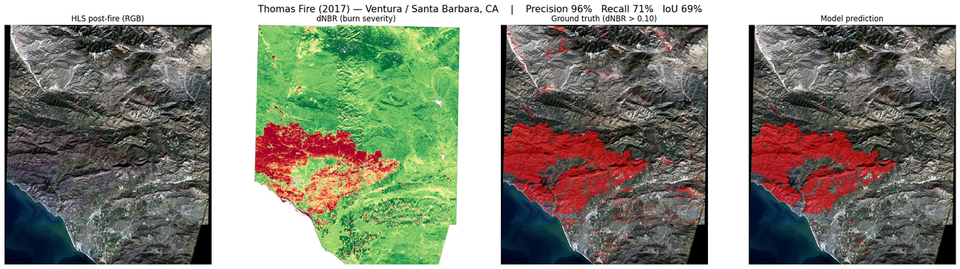

In [4]:
show_fire("thomas_fire_2017")

In [ ]:
show_fire("palisades_fire_2025")

In [ ]:
show_fire("eaton_fire_2025")

## Frozen encoder vs fine-tuned encoder

Both models use the **same Prithvi-EO-2.0-300M encoder + FPN decoder**; they differ only in
the training recipe — `balanced_chaparral` keeps the encoder **frozen** (decoder-only), while
`finetune_v2` **unfreezes the encoder** partway through with layer-wise LR decay. This is a
*pipeline comparison* (two end-to-end recipes), **not a controlled ablation** — the runs differ
in more than the frozen/unfrozen flag.

The cells below load each run's training history (`history.pt`) and compare held-out
test-fire metrics.

In [ ]:
import torch, xarray as xr
from pathlib import Path
from src.data import _restore_crs, load_config
from src.model import BurnScarModel
from src.utils import get_device
from run_inference import run_inference

Path('results').mkdir(exist_ok=True)
FROZEN_DIR    = Path('checkpoints/balanced_chaparral')
FINETUNED_DIR = Path('checkpoints/finetune_v2')

def load_history(ckpt_dir):
    return torch.load(ckpt_dir / 'history.pt', map_location='cpu', weights_only=False)

frozen_hist    = load_history(FROZEN_DIR)
finetuned_hist = load_history(FINETUNED_DIR)

ft_cfg = load_config('configs/finetune_config.yaml')
unfreeze_epoch = ft_cfg['model']['unfreeze_after_epoch']

# --- training curves (finetune_v2 is the deployed run) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for hist, label, color in [
    (frozen_hist,    'Frozen encoder',     '#2196F3'),
    (finetuned_hist, 'Fine-tuned encoder', '#F44336'),
]:
    ep = range(1, len(hist['train']) + 1)
    axes[0].plot(ep, [m['loss']     for m in hist['val']],   '-', color=color, label=label, lw=2)
    axes[0].plot(ep, [m['loss']     for m in hist['train']], '-', color=color, alpha=0.35, lw=1)
    axes[1].plot(ep, [m['mean_iou'] for m in hist['val']],   '-', color=color, label=label, lw=2)
    axes[1].plot(ep, [m['mean_iou'] for m in hist['train']], '-', color=color, alpha=0.35, lw=1)

axes[1].axvline(x=unfreeze_epoch + 0.5, color='#F44336', ls='--', alpha=0.5, label='Encoder unfrozen')
for ax, title, ylabel in zip(axes, ['Validation Loss', 'Validation IoU'], ['Loss', 'Mean IoU']):
    ax.set(xlabel='Epoch', ylabel=ylabel, title=title); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Prithvi-EO-2.0 encoder: frozen vs fine-tuned (finetune_v2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/frozen_vs_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- held-out test-fire comparison (both Prithvi-EO-2.0) ---
# Runs each checkpoint on the cached scenes. Heavy (loads the 300M encoder); the
# fine-tuned side also matches data/predictions/*.npz produced by run_inference.py.
cfg    = load_config('configs/train_config.yaml')
cache  = Path(cfg['data']['cache_dir'])
bands  = cfg['data']['bands']
ps     = cfg['data']['patch_size']
dnbr_t = cfg['data'].get('dnbr_threshold', 0.10)
device = get_device()
TEST_FIRES = ['woolsey_fire_2018', 'thomas_fire_2017', 'palisades_fire_2025', 'eaton_fire_2025']

def eval_checkpoint(ckpt_path):
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = BurnScarModel(num_classes=cfg['model']['num_classes'],
                          in_channels=cfg['model']['in_channels'])
    model.load_state_dict(state['model_state_dict'])
    model.to(device).eval()
    results = {}
    for fire in TEST_FIRES:
        pre  = _restore_crs(xr.open_dataset(cache / f'{fire}_pre.nc',  engine='h5netcdf'))
        post = _restore_crs(xr.open_dataset(cache / f'{fire}_post.nc', engine='h5netcdf')).rio.reproject_match(pre)
        pred, true, _ = run_inference(model, post, pre, bands=bands,
                                      patch_size=ps, device=device, dnbr_threshold=dnbr_t)
        tp = int(((pred==1)&(true==1)).sum())
        fp = int(((pred==1)&(true==0)).sum())
        fn = int(((pred==0)&(true==1)).sum())
        results[fire] = dict(precision=tp/(tp+fp) if tp+fp else 0,
                             recall=tp/(tp+fn)    if tp+fn else 0,
                             iou=tp/(tp+fp+fn)    if tp+fp+fn else 0)
    return results

frozen_r    = eval_checkpoint(FROZEN_DIR    / 'best_model.pt')
finetuned_r = eval_checkpoint(FINETUNED_DIR / 'best_model.pt')

print(f"{'Fire':<26} {'Frozen encoder':>22} {'Fine-tuned encoder':>22}")
print(f"{'':26} {'P / R / IoU':>22} {'P / R / IoU':>22}")
print('-' * 72)
for fire in TEST_FIRES:
    f, t = frozen_r[fire], finetuned_r[fire]
    print(f"{fire:<26} {f['precision']:6.3f}/{f['recall']:6.3f}/{f['iou']:6.3f}  "
          f"    {t['precision']:6.3f}/{t['recall']:6.3f}/{t['iou']:6.3f}")
macro_f = {m: np.mean([v[m] for v in frozen_r.values()])    for m in ['precision','recall','iou']}
macro_t = {m: np.mean([v[m] for v in finetuned_r.values()]) for m in ['precision','recall','iou']}
print('-' * 72)
print(f"{'MACRO':<26} {macro_f['precision']:6.3f}/{macro_f['recall']:6.3f}/{macro_f['iou']:6.3f}  "
      f"    {macro_t['precision']:6.3f}/{macro_t['recall']:6.3f}/{macro_t['iou']:6.3f}")

## Baseline: official Prithvi-EO-2.0-300M-BurnScars

How does our fine-tune compare to IBM/NASA's **official** burn-scar model,
[`ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars`](https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars)?
That model is distributed for [TerraTorch](https://github.com/IBM/terratorch) and ships its own
segmentation head + normalization. We run it on the **same cached scenes and the same dNBR labels**
as above, at a fixed 0.5 threshold, so the only thing that differs is the model.

This cell needs `terratorch` and the model weights, so it is meant to run on the cloud GPU box:

```bash
pip install terratorch
```


In [ ]:
# Official Prithvi-EO-2.0-300M-BurnScars vs ours, on the four held-out fires.
# Reuses our cached scenes (raw reflectance) and dNBR labels for an apples-to-apples
# P/R/IoU. Normalization is read from the model's own TerraTorch config — nothing
# burn-scar-specific is hardcoded here. Runs on the cloud box (terratorch + GPU).
import numpy as np

BURNSCARS_REPO = "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-BurnScars"

def run_official_burnscars():
    import torch, yaml, xarray as xr
    from pathlib import Path
    from huggingface_hub import hf_hub_download
    from src.data import _restore_crs, load_config, generate_burn_mask
    from src.utils import get_device

    try:
        from terratorch.cli_tools import LightningInferenceModel
    except ImportError as e:
        raise ImportError(
            "terratorch is required for the official BurnScars model "
            "(`pip install terratorch`). Run this cell on the cloud GPU box."
        ) from e

    cfg    = load_config("configs/train_config.yaml")
    cache  = Path(cfg["data"]["cache_dir"])
    bands  = cfg["data"]["bands"]
    ps     = cfg["data"]["patch_size"]
    dnbr_t = cfg["data"].get("dnbr_threshold", 0.10)
    device = get_device()
    TEST_FIRES = ["woolsey_fire_2018", "thomas_fire_2017",
                  "palisades_fire_2025", "eaton_fire_2025"]

    # Build the official model from its published TerraTorch config + checkpoint.
    config_path = hf_hub_download(BURNSCARS_REPO, "config.yaml")
    ckpt_path   = hf_hub_download(BURNSCARS_REPO, "Prithvi_EO_V2_300M_BurnScars.pt")
    lit = LightningInferenceModel.from_config(config_path, ckpt_path)
    model = lit.model.to(device).eval()

    # Per-band normalization from the model's own config (no hardcoded constants).
    raw_cfg = yaml.safe_load(open(config_path))
    dm = raw_cfg.get("data", {}).get("init_args", {})
    means = np.asarray(dm["means"], dtype=np.float32)
    stds  = np.asarray(dm["stds"], dtype=np.float32)

    @torch.no_grad()
    def infer(post_ds):
        # Raw reflectance in band order, normalized with the BurnScars stats.
        arr = np.stack([post_ds[b].values.astype(np.float32) for b in bands], 0)
        # config means/stds are typically in DN (reflectance*10000); match scale.
        scale = 10000.0 if means.max() > 1.5 else 1.0
        img = (arr * scale - means[:, None, None]) / stds[:, None, None]
        _, h, w = img.shape
        acc = np.zeros((h, w), np.float32); cnt = np.zeros((h, w), np.float32)
        valid = ~(np.isnan(arr).any(0) | (np.nan_to_num(arr).max(0) == 0))
        stride = ps // 2
        ys = list(range(0, max(1, h - ps + 1), stride)) or [0]
        xs = list(range(0, max(1, w - ps + 1), stride)) or [0]
        if ys[-1] != h - ps: ys.append(max(0, h - ps))
        if xs[-1] != w - ps: xs.append(max(0, w - ps))
        for y in ys:
            for x in xs:
                patch = np.nan_to_num(img[:, y:y+ps, x:x+ps], nan=0.0)
                t = torch.from_numpy(patch).unsqueeze(0).float().to(device)
                out = model(t)
                logits = out.output if hasattr(out, "output") else out
                prob = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()
                acc[y:y+ps, x:x+ps] += prob; cnt[y:y+ps, x:x+ps] += 1
        prob = np.divide(acc, cnt, out=np.zeros_like(acc), where=cnt > 0)
        pred = (prob > 0.5).astype(np.uint8); pred[~valid] = 0
        return pred

    results = {}
    for fire in TEST_FIRES:
        pre  = _restore_crs(xr.open_dataset(cache / f"{fire}_pre.nc",  engine="h5netcdf"))
        post = _restore_crs(xr.open_dataset(cache / f"{fire}_post.nc", engine="h5netcdf")).rio.reproject_match(pre)
        true = generate_burn_mask(pre, post, dnbr_threshold=dnbr_t)
        pred = infer(post)
        tp = int(((pred==1)&(true==1)).sum()); fp = int(((pred==1)&(true==0)).sum())
        fn = int(((pred==0)&(true==1)).sum())
        results[fire] = dict(precision=tp/(tp+fp) if tp+fp else 0,
                             recall=tp/(tp+fn)    if tp+fn else 0,
                             iou=tp/(tp+fp+fn)    if tp+fp+fn else 0)
    return results

try:
    official_r = run_official_burnscars()
    print(f"{'Fire':<26} {'Official BurnScars':>22}")
    print(f"{'':26} {'P / R / IoU':>22}")
    print('-' * 50)
    for fire, m in official_r.items():
        print(f"{fire:<26} {m['precision']:6.3f}/{m['recall']:6.3f}/{m['iou']:6.3f}")
    macro = {k: np.mean([v[k] for v in official_r.values()]) for k in ['precision','recall','iou']}
    print('-' * 50)
    print(f"{'MACRO':<26} {macro['precision']:6.3f}/{macro['recall']:6.3f}/{macro['iou']:6.3f}")
    print("\nCompare against our fine-tune's MACRO from the table above.")
except Exception as e:
    print(f"Skipped (run on cloud with terratorch): {type(e).__name__}: {e}")


## Methods & honesty notes

- **No test-set leakage.** The decision threshold was calibrated on training fires only; the water mask is a physics-based spectral index (NDWI). Neither touches the held-out fires.
- **Water exclusion.** Open water makes NBR pure noise (NIR ≈ SWIR ≈ 0), so both the model and the dNBR label spuriously flag it as burned. An NDWI mask removes it deterministically.
- **Cloud/shadow/snow.** Per-granule HLS Fmask masking (cloud, cloud shadow, snow) removes contaminated pixels before mosaicking, so they neither train nor evaluate the model.

## Limitations & future work

- Residual over-prediction remains on dry chaparral hillsides.
- The training set is 37 geographically diverse fires; a global expansion (~100 fires) and an Optuna hyperparameter search are set up to run on cloud GPU hardware (see `scripts/optuna_search.py`).

## Hyperparameter search (Optuna)

Pending the cloud run of `scripts/optuna_search.py`. Once `checkpoints/optuna/` is pulled
back from S3, the cell below loads the study and shows the best trial, parameter importances,
and the optimization trajectory.

In [ ]:
# Populated after the Optuna search runs on the cloud (checkpoints/optuna/).
import joblib, yaml
from pathlib import Path

opt_dir = Path('checkpoints/optuna')
if (opt_dir / 'study.pkl').exists():
    study = joblib.load(opt_dir / 'study.pkl')
    print('Best val mean-IoU:', round(study.best_value, 4))
    print('Best params:', yaml.safe_load((opt_dir / 'best_params.yaml').read_text()))
    import optuna
    from optuna.visualization.matplotlib import plot_param_importances, plot_optimization_history
    plot_optimization_history(study); plt.tight_layout(); plt.show()
    if len(study.trials) > 1:
        plot_param_importances(study); plt.tight_layout(); plt.show()
else:
    print('No Optuna study yet — run scripts/optuna_search.py on the cloud, then '
          'pull checkpoints/optuna/ from S3.')